<a href="https://colab.research.google.com/github/josorio398/ALGEBRA-LINEAL-CON-PYTHON/blob/master/SAM_Aplicaci%C3%B3n_clasificaci%C3%B3n_de_chaquiras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center> <font size="6"><b> SEGMENTACIÓN DE IMÁGENES CON SAM</b>
<center> (Segment Anything Model)<center>

#   **Instalación de SAM y OpenCV**


In [ ]:
%%capture
import sys
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

#  **Descarga de archivos**

In [ ]:
%%capture
!mkdir images
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg
!wget -P images https://raw.githubusercontent.com/josorio398/Hyperspectral_Images_Analysis/main/imagenes_sam/PlantaD1.jpg
!wget -P images https://raw.githubusercontent.com/josorio398/Hyperspectral_Images_Analysis/main/imagenes_sam/calendula.jpg
!wget -P images https://raw.githubusercontent.com/josorio398/Hyperspectral_Images_Analysis/main/imagenes_sam/RGB_CPS.jpg
!wget -P images https://raw.githubusercontent.com/josorio398/Hyperspectral_Images_Analysis/main/imagenes_sam/Chaquiras_desordenadas.jpg


#  **Descarga archivo de preentrenamiento**

In [ ]:
%%capture
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

# **Importación librerias**

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision #para colab
import pandas as pd
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

#   **Función para visualizar las mascaras de segmentación**

In [ ]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

#   **Función para convertir al espacio de color LAB**

In [ ]:
def show_all_lab_channels(mask_image):
    # Convertir la imagen a espacio de color LAB
    lab_image = cv2.cvtColor(mask_image, cv2.COLOR_RGB2LAB)

    # Extraer los canales L, A y B
    l_channel, a_channel, b_channel = cv2.split(lab_image)

    # Crear una figura y subtramas
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

    # Mostrar el canal L
    axs[0].imshow(l_channel, cmap='gray')
    axs[0].set_title('Canal L')
    axs[0].axis('off')

    # Mostrar el canal A
    axs[1].imshow(a_channel, cmap='gray')
    axs[1].set_title('Canal A')
    axs[1].axis('off')

    # Mostrar el canal B
    axs[2].imshow(b_channel, cmap='gray')
    axs[2].set_title('Canal B')
    axs[2].axis('off')

    # Mostrar la figura
    plt.show()

#  **Imagen de ejemplo**

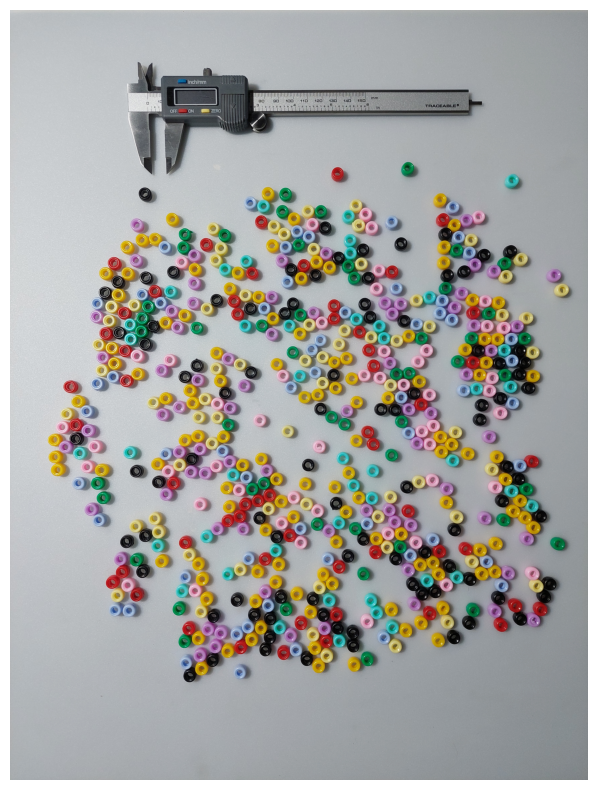

In [ ]:
# Cargando la imagen
image_path = '/content/images/Chaquiras_desordenadas.jpg'  # Actualice la ruta según su configuración
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('off')
plt.show()

#  **Generador de mascaras**

In [ ]:
# Configuración
sam_checkpoint = "sam_vit_h_4b8939.pth"  # Ubicación del modelo preentrenado
model_type = "vit_h"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Cargando el modelo
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)


# Redimensionar la imagen
scale_percent = 60  # Porcentaje de la escala original. En este caso, se reduce a un 60%
width = int(image.shape[1] * scale_percent / 100)
height = int(image.shape[0] * scale_percent / 100)
dim = (width, height)
resized_image = cv2.resize(image, dim, interpolation = cv2.INTER_AREA)

# Generación de máscaras
mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(resized_image)

In [ ]:
def generate_masks(image, scale_percent):
    # Configuración
    sam_checkpoint = "sam_vit_h_4b8939.pth"  # Ubicación del modelo preentrenado
    model_type = "vit_h"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Cargando el modelo
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    sam.to(device=device)

    # Redimensionar la imagen
    width = int(image.shape[1] * scale_percent / 100)
    height = int(image.shape[0] * scale_percent / 100)
    dim = (width, height)
    resized_image = cv2.resize(image, dim, interpolation=cv2.INTER_LINEAR)

    # Generación de máscaras
    mask_generator = SamAutomaticMaskGenerator(sam)
    masks = mask_generator.generate(resized_image)

    return masks, resized_image

# Generación de máscaras
scale_percent = 65  # Aumenta el tamaño de la imagen en un 20%
masks, resized_image = generate_masks(image, scale_percent)

print(len(masks))

296


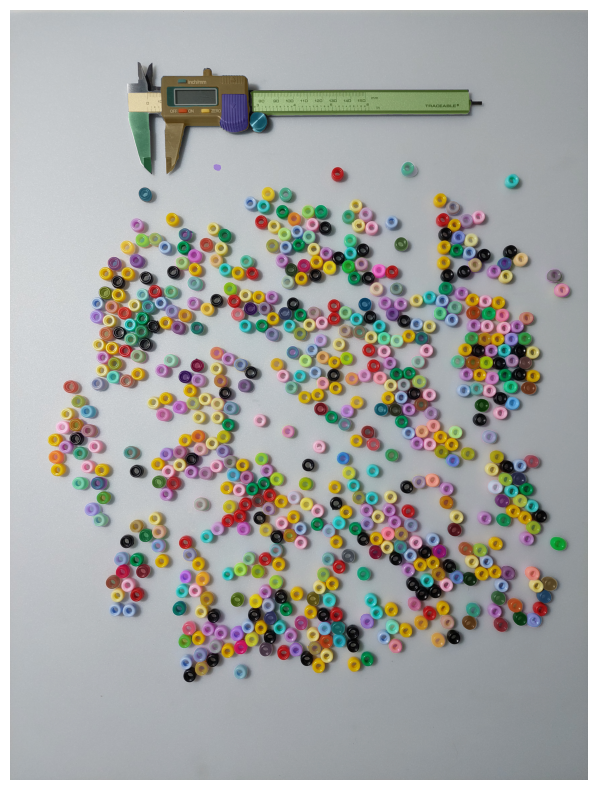

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(resized_image )
show_anns(masks)
plt.axis('off')
plt.show()

In [ ]:
print(len(masks))

296


In [ ]:
from skimage import color
import numpy as np

def classify_colors(image, masks):
    # Convertir la imagen a CIELAB
    image_lab = color.rgb2lab(image)

    # Diccionario para almacenar los colores promedio de cada máscara
    mask_colors = {}

    for i, mask in enumerate(masks):
        # Aplicar la máscara a la imagen
        mask_image = image_lab * np.expand_dims(mask['segmentation'], axis=2)

        # Calcular el color promedio de la máscara
        avg_color = mask_image[mask['segmentation']].mean(axis=0)

        mask_colors[i] = avg_color

    return mask_colors

# Clasificar los colores
mask_colors = classify_colors(resized_image, masks)

# Imprimir los colores promedio de cada máscara
for i, color in mask_colors.items():
    print(f"Mask {i}: {color}")

Mask 0: [37.33540489 47.41666649 32.85162372]
Mask 1: [20.51465486  3.3338971  -1.33434254]
Mask 2: [57.03919739  2.85491439 59.9755627 ]
Mask 3: [83.15749587 -0.2297625  -0.62266451]
Mask 4: [10.66253831 -0.62658248 -0.18522463]
Mask 5: [63.96573158 21.29535801 -2.4954996 ]
Mask 6: [66.04564923 -4.20196754 31.87190082]
Mask 7: [ 40.6861915  -31.76139946  14.48255787]
Mask 8: [62.56845212  8.38751574 54.79427139]
Mask 9: [38.39011624 44.3926391  28.51085598]
Mask 10: [63.20381106  4.01613575 61.35823804]
Mask 11: [65.49323871 -3.35877971 35.69166103]
Mask 12: [19.79988426  0.60991426 -0.77507052]
Mask 13: [64.53185186 21.96909972 -2.85371104]
Mask 14: [ 61.09813285 -29.18378891  -6.22097857]
Mask 15: [66.0310561   2.80734483 58.28519671]
Mask 16: [64.74641567  4.09507271 59.11115964]
Mask 17: [65.68208009 -4.4624573  34.9668907 ]
Mask 18: [60.85179439  4.66220902 57.52402937]
Mask 19: [68.83717768 -3.10931943 31.75720998]
Mask 20: [35.01041014  0.09365904 -4.038303  ]
Mask 21: [ 60.345

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

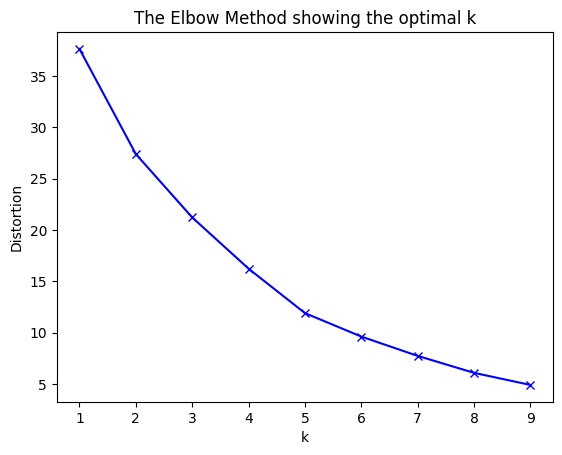

Mask 0 belongs to color group 4
Mask 1 belongs to color group 2
Mask 2 belongs to color group 6
Mask 3 belongs to color group 5
Mask 4 belongs to color group 2
Mask 5 belongs to color group 0
Mask 6 belongs to color group 1
Mask 7 belongs to color group 3
Mask 8 belongs to color group 6
Mask 9 belongs to color group 4
Mask 10 belongs to color group 6
Mask 11 belongs to color group 1
Mask 12 belongs to color group 2
Mask 13 belongs to color group 0
Mask 14 belongs to color group 7
Mask 15 belongs to color group 6
Mask 16 belongs to color group 6
Mask 17 belongs to color group 1
Mask 18 belongs to color group 6
Mask 19 belongs to color group 1
Mask 20 belongs to color group 9
Mask 21 belongs to color group 7
Mask 22 belongs to color group 0
Mask 23 belongs to color group 0
Mask 24 belongs to color group 6
Mask 25 belongs to color group 2
Mask 26 belongs to color group 8
Mask 27 belongs to color group 2
Mask 28 belongs to color group 0
Mask 29 belongs to color group 8
Mask 30 belongs to c

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# Convertir los colores de las máscaras a una matriz NumPy para el clustering
mask_colors_array = np.array(list(mask_colors.values()))

# Calcular el número óptimo de clusters usando el método del codo
distortions = []
K = range(1, 10)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(mask_colors_array)
    distortions.append(sum(np.min(cdist(mask_colors_array, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / mask_colors_array.shape[0])

# Plot the elbow
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

# Asumiendo que el número óptimo de clusters es 3
kmeans = KMeans(n_clusters=10, random_state=0).fit(mask_colors_array)

# Imprimir a qué cluster pertenece cada máscara
for i, label in enumerate(kmeans.labels_):
    print(f"Mask {i} belongs to color group {label}")

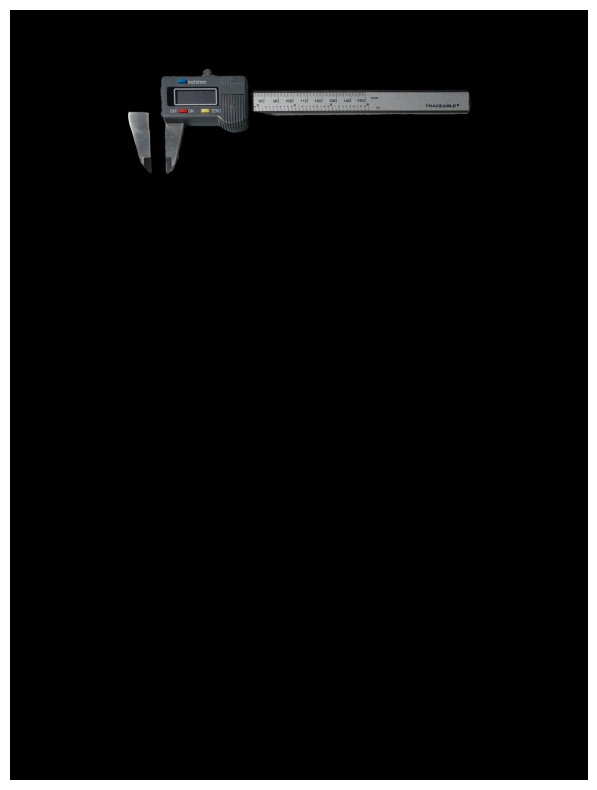

In [ ]:
# Supongamos que kmeans.labels_ contiene las etiquetas de los clusters de cada máscara
# y que deseas visualizar todas las máscaras que pertenecen al cluster 0
selected_cluster = 9
mask_indices = [i for i, label in enumerate(kmeans.labels_) if label == selected_cluster]

# Crear una imagen vacía de tamaño similar a la imagen original
mask_image = np.zeros_like(resized_image)

# Aplicar cada máscara seleccionada a la imagen
for mask_index in mask_indices:
    selected_mask = masks[mask_index]
    mask_image[selected_mask['segmentation']] = resized_image[selected_mask['segmentation']]

# Visualizar la imagen de las máscaras
plt.figure(figsize=(10,10))
plt.imshow(mask_image)
plt.axis('off')
plt.show()

In [ ]:
# Supongamos que kmeans.labels_ contiene las etiquetas de los clusters de cada máscara
# y que deseas saber el número de máscaras en el cluster 0
mask_indices = [i for i, label in enumerate(kmeans.labels_) if label == selected_cluster]

# El número de máscaras en el cluster seleccionado es simplemente la longitud de mask_indices
num_masks_in_cluster = len(mask_indices)

print(f"El número de máscaras en el cluster {selected_cluster} es {num_masks_in_cluster}")

El número de máscaras en el cluster 9 es 7


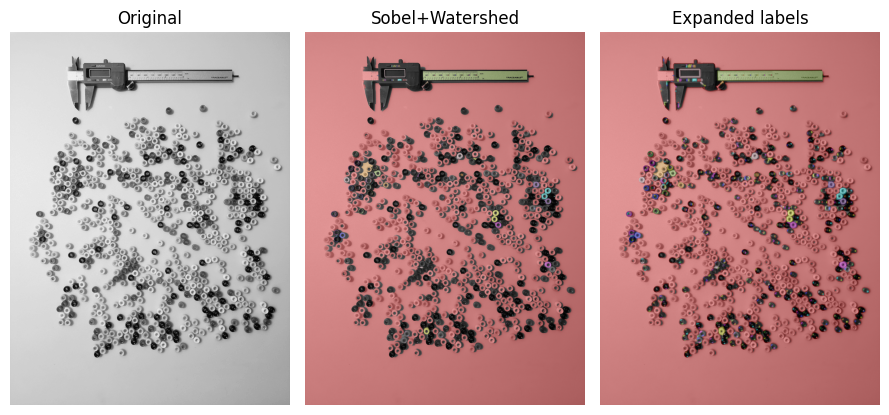

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, color, filters, measure, segmentation
from skimage.color import label2rgb

# Cargamos la imagen
img_path = "/content/images/Chaquiras_desordenadas.jpg"  # Ruta de la imagen
image = io.imread(img_path)

# Convertimos la imagen a escala de grises
coins = color.rgb2gray(image)

# Realizamos la segmentación usando detección de bordes y watershed.
edges = filters.sobel(coins)

# Identificamos algunos píxeles de fondo y primer plano a partir de los valores de intensidad.
# Estos píxeles se usan como semillas para watershed.
markers = np.zeros_like(coins)
foreground, background = 1, 2
markers[coins < 0.3] = background
markers[coins > 0.7] = foreground

ws = segmentation.watershed(edges, markers)
seg1 = measure.label(ws == foreground)

# Expande las etiquetas
expanded = segmentation.expand_labels(seg1, distance=10)

# Muestra las segmentaciones.
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(9, 5),
    sharex=True,
    sharey=True,
)

axes[0].imshow(coins, cmap="Greys_r")
axes[0].set_title("Original")

color1 = label2rgb(seg1, image=coins, bg_label=0)
axes[1].imshow(color1)
axes[1].set_title("Sobel+Watershed")

color2 = label2rgb(expanded, image=coins, bg_label=0)
axes[2].imshow(color2)
axes[2].set_title("Expanded labels")

for a in axes:
    a.axis("off")
fig.tight_layout()
plt.show()

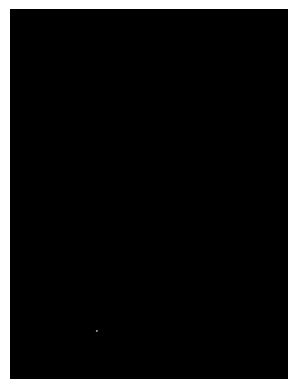

In [ ]:
import matplotlib.pyplot as plt

# Seleccionar una región de la segmentación
selected_label = 588
selected_region = (expanded == selected_label)

# Imprimir la región seleccionada
plt.imshow(selected_region, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
unique_labels = np.unique(expanded)
print(unique_labels)

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

In [ ]:
from sklearn.cluster import KMeans

def classify_colors(image, labels, n_colors=5):
    # Convertir la imagen a CIELAB
    image_lab = color.rgb2lab(image)

    # Diccionario para almacenar los colores promedio de cada label
    label_colors = {}

    for label in np.unique(labels):
        # Aplicar la máscara a la imagen
        mask = labels == label
        mask_image = image_lab * np.expand_dims(mask, axis=2)

        # Preparar los datos para KMeans
        pixels = mask_image[mask].reshape(-1, 3)

        # Usar KMeans para clasificar los colores
        kmeans = KMeans(n_clusters=n_colors, n_init=10)
        kmeans.fit(pixels)
        colors = kmeans.cluster_centers_

        label_colors[label] = colors

    return label_colors

# Clasificar los colores
label_colors = classify_colors(image, expanded)

# Imprimir los colores promedio de cada label
for label, colors in label_colors.items():
    print(f"Label {label}: {colors}")

Label 0: [[ 39.99507778  23.55956509  -3.8315354 ]
 [  7.46173868   0.08864731  -0.36353441]
 [ 41.85930119 -39.50035892  20.61969316]
 [ 36.36494386  -1.45119574   0.56704911]
 [ 35.76811554  48.20257597  35.63384875]]
Label 1: [[78.4924531  -0.60928955 -1.79433711]
 [66.9174093   1.4473148  56.18440055]
 [36.86660547 -0.66811462  5.14199473]
 [52.67876027 28.21519761 -8.47834858]
 [65.9610682  -1.38430757 -2.60787905]]
Label 2: [[ 3.77403585e+01  4.69349247e-01  6.48167740e-01]
 [ 5.97093747e+01  5.35701655e-03  7.51870135e-01]
 [ 7.21711214e+01  7.79912138e-01  5.45561963e-01]
 [ 4.15524277e+01  1.90105044e-01  7.31212758e-01]
 [ 5.04575483e+01 -1.05857614e-01  1.07936947e+00]]
Label 3: [[50.22572218 -1.6777884  -3.64038264]
 [75.30367663 -1.62942755 -2.90688183]
 [28.33532248 -1.61215466 -4.23976681]
 [64.24813448 -2.00908024 -3.20637372]
 [36.37523249 -1.42519375 -3.79093775]]
Label 4: [[37.53310287 -1.1449129  -4.74335324]
 [58.46187462 -0.63962427 -4.5379441 ]
 [28.77919013 -0.8

In [ ]:
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# Convertir los colores de las etiquetas a una matriz NumPy para el clustering
label_colors_array = []
for label, colors in label_colors.items():
    label_colors_array.extend(colors)
label_colors_array = np.array(label_colors_array)

# Calcular el número óptimo de clusters usando el método del codo
distortions = []
K = range(1, 10)
for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(label_colors_array)
    distortions.append(sum(np.min(cdist(label_colors_array, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / label_colors_array.shape[0])

# Plot the elbow
plt.plot(K, distortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Distortion')
plt.title('The Elbow Method showing the optimal k')
plt.show()

# Asumiendo que el número óptimo de clusters es 3
kmeans = KMeans(n_clusters=10, random_state=0).fit(label_colors_array)

# Imprimir a qué cluster pertenece cada color de etiqueta
color_labels = kmeans.labels_
counter = 0
for label, colors in label_colors.items():
    for _ in colors:
        print(f"Color {counter} of Label {label} belongs to color group {color_labels[counter]}")
        counter += 1

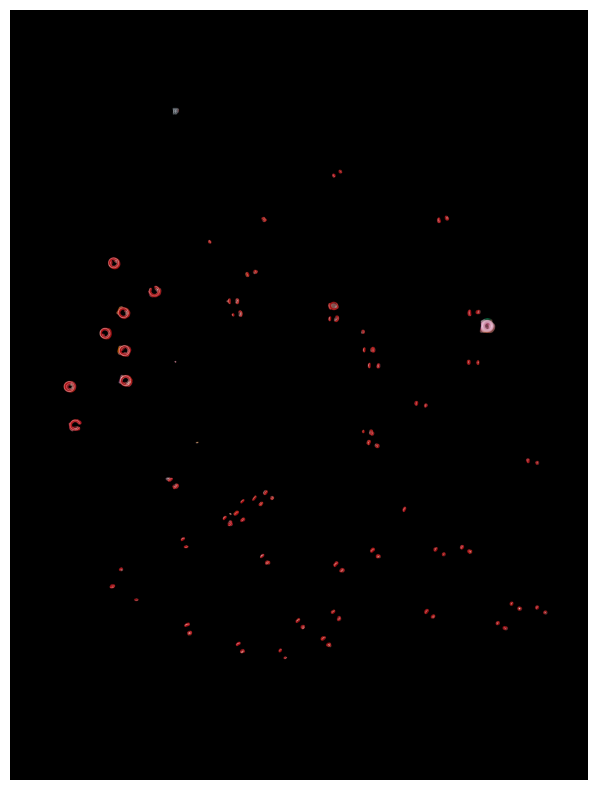

In [ ]:
def get_mask(labels, label):
    """
    Función para generar una máscara para una etiqueta específica
    """
    return np.where(labels == label, 1, 0)


# Supongamos que color_labels contiene las etiquetas de los clusters de cada color de etiqueta
# y que deseas visualizar todas las etiquetas que tienen al menos un color perteneciente al cluster 9
selected_cluster = 9
label_indices = [i for i, label in enumerate(color_labels) if label == selected_cluster]

# Crear una imagen vacía de tamaño similar a la imagen original
mask_image = np.zeros_like(image)

# Recopilar los índices de etiquetas únicos de los índices de colores seleccionados
selected_labels = set(label // 5 for label in label_indices)  # Asumiendo que cada etiqueta tiene exactamente 5 colores

# Aplicar cada máscara seleccionada a la imagen
for label in selected_labels:
    selected_mask = get_mask(expanded, label)
    mask_image[selected_mask == 1] = image[selected_mask == 1]

# Visualizar la imagen de las máscaras
plt.figure(figsize=(10,10))
plt.imshow(mask_image)
plt.axis('off')
plt.show()

In [ ]:
# Suponemos que color_labels contiene las etiquetas de los grupos de cada color de etiqueta
# y que deseas saber el número de etiquetas que tienen al menos un color en el cluster 9
selected_cluster = 9
label_indices = [i for i, label in enumerate(color_labels) if label == selected_cluster]

# Recopilar los índices de etiquetas únicos de los índices de colores seleccionados
selected_labels = set(label // 5 for label in label_indices)  # Asumiendo que cada etiqueta tiene exactamente 5 colores

# El número de etiquetas en el grupo seleccionado es simplemente la longitud de selected_labels
num_labels_in_cluster = len(selected_labels)

print(f"El número de etiquetas en el cluster {selected_cluster} es {num_labels_in_cluster}")

El número de etiquetas en el cluster 9 es 130


# **Información de las máscaras**

La generación de máscaras devuelve una lista de máscaras, donde cada máscara es un diccionario que contiene varios datos sobre la máscara. Estas claves son:

- **segmentation** : la máscara
- **area** : el área de la máscara en píxeles
- **bbox** : el cuadro delimitador de la máscara en formato XYWH
- **predicted_iou** : la propia predicción del modelo para la calidad de la máscara
- **point_coords** : el punto de entrada muestreado que generó esta máscara
- **stability_score** : una medida adicional de la calidad de la máscara
- **crop_box** : el recorte de la imagen utilizado para generar esta máscara en formato XYWH

In [ ]:
len(masks)

296

In [ ]:
masks[1]['area']

2326

##  **Extracción de mascaras**

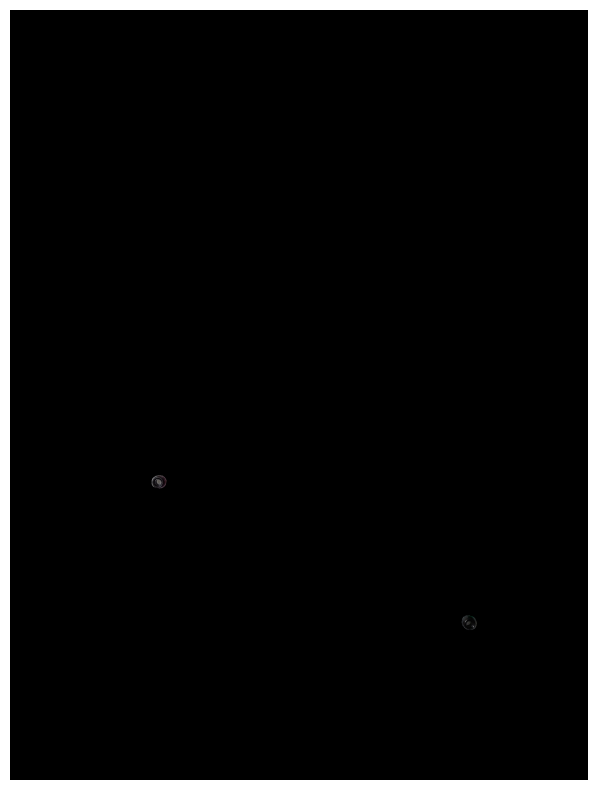

In [ ]:
mask_indices = [1,4]  # Cambia esta lista a los índices que prefieras

# Crear una imagen vacía de tamaño similar a la imagen original
mask_image = np.zeros_like(resized_image)

# Aplicar cada máscara seleccionada a la imagen
for mask_index in mask_indices:
    selected_mask = masks[mask_index]
    mask_image[selected_mask['segmentation']] = resized_image[selected_mask['segmentation']]

# Visualizar la imagen de las máscaras
plt.figure(figsize=(10,10))
plt.imshow(mask_image)
plt.axis('off')
plt.show()

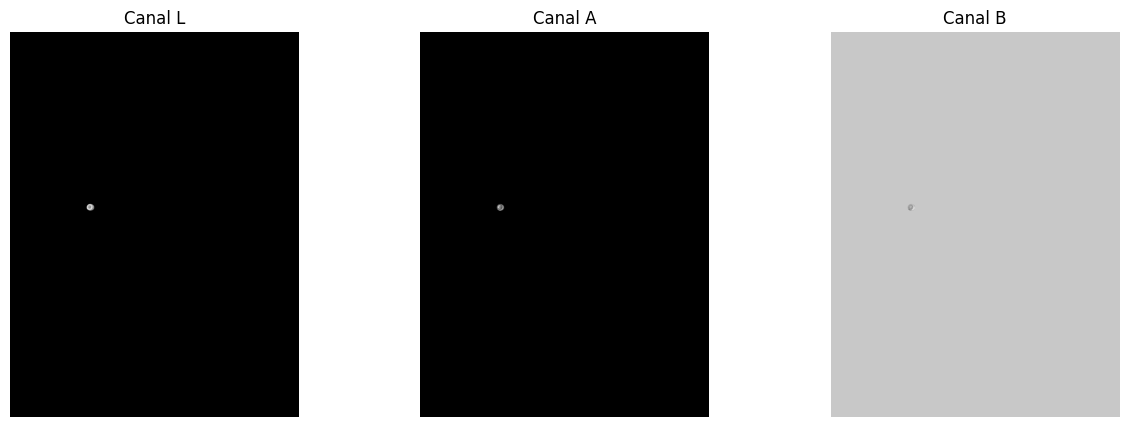

In [ ]:
show_all_lab_channels(mask_image)

#  **Información de la imagen generada**



In [ ]:
# Lista para almacenar la información de las máscaras
mask_info = []

# Aplicar cada máscara seleccionada a la imagen
for mask_index in mask_indices:
    selected_mask = masks[mask_index]
    mask_image[selected_mask['segmentation']] = resized_image[selected_mask['segmentation']]

    # Agregar información de la máscara a la lista
    mask_info.append({
        'Mask Index': mask_index,
        'Area': selected_mask['area']
    })

# Crear un DataFrame a partir de la lista de información de las máscaras
mask_df = pd.DataFrame(mask_info)

# Calcular el total del área de las máscaras seleccionadas
total_area = mask_df['Area'].sum()

# Agregar una fila al DataFrame con el total del área
mask_df = mask_df.append({'Mask Index': 'Total', 'Area': total_area}, ignore_index=True)

mask_df

<ipython-input-25-0fdc28acf6d4>:22: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mask_df = mask_df.append({'Mask Index': 'Total', 'Area': total_area}, ignore_index=True)


,Mask Index,Area
0,1,1978
1,Total,1978


#  **Eliminación de máscaras**

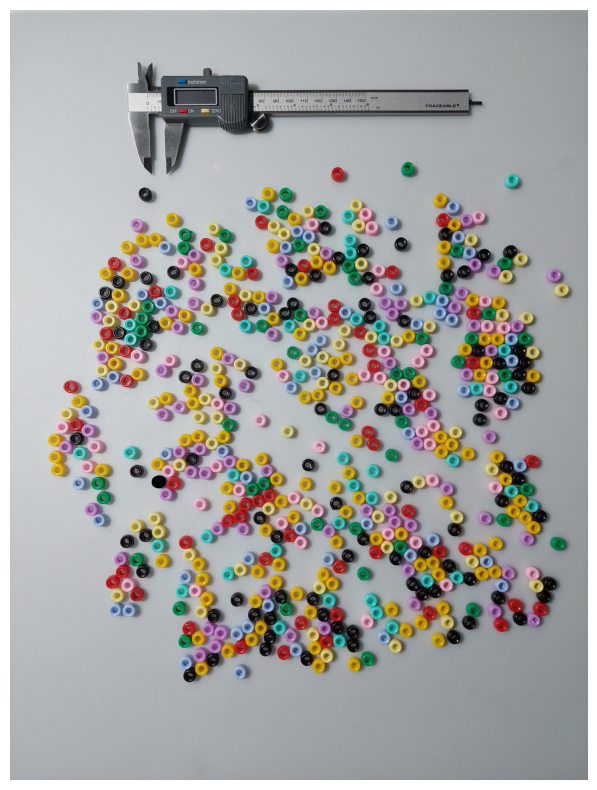

In [ ]:
mask_indices = [1]  # Cambia esta lista a los índices que prefieras

# Crear una copia de la imagen original
mask_image = np.copy(resized_image)

# Aplicar cada máscara seleccionada a la imagen
for mask_index in mask_indices:
    selected_mask = masks[mask_index]
    mask_image[selected_mask['segmentation']] = [0, 0, 0]  # Cambia a cualquier otro color si prefieres

# Visualizar la imagen de las máscaras
plt.figure(figsize=(10,10))
plt.imshow(mask_image)
plt.axis('off')
plt.show()

#  **Información de la imagen generada**


In [ ]:
# Lista para almacenar la información de las máscaras
mask_info = []

# Aplicar cada máscara seleccionada a la imagen
for mask_index in range(len(masks)):
    if mask_index in mask_indices:
        # Esta es una máscara que queremos ocultar
        selected_mask = masks[mask_index]
        mask_image[selected_mask['segmentation']] = [0, 0, 0]  # Cambia a cualquier otro color si prefieres
    else:
        # Esta es una máscara que queremos mostrar
        selected_mask = masks[mask_index]

        # Agregar información de la máscara a la lista
        mask_info.append({
            'Mask Index': mask_index,
            'Area': selected_mask['area']
        })

# Crear un DataFrame a partir de la lista de información de las máscaras
mask_df = pd.DataFrame(mask_info)

# Calcular el total del área de las máscaras seleccionadas
total_area = mask_df['Area'].sum()

# Agregar una fila al DataFrame con el total del área
mask_df = mask_df.append({'Mask Index': 'Total', 'Area': total_area}, ignore_index=True)

mask_df


<ipython-input-32-2b16c09eab96>:27: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mask_df = mask_df.append({'Mask Index': 'Total', 'Area': total_area}, ignore_index=True)


,Mask Index,Area
0,1,231638
1,2,81368
2,3,41626
3,4,71953
4,5,155390
5,6,34909
6,7,156447
7,8,69604
8,9,73442
9,10,33265


##  **limpiar caché de la cuda**

In [ ]:
torch.cuda.empty_cache()